In [1]:
from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# Notebook location: C:\Users\aryav\geovision\notebooks
# Project location: C:\Users\aryav\geovision
PROJECT_ROOT = Path.cwd().parent

data_raw_dir = PROJECT_ROOT / "data" / "raw"
data_labels_dir = PROJECT_ROOT / "data" / "labels"
models_dir = PROJECT_ROOT / "models"
outputs_maps_dir = PROJECT_ROOT / "outputs" / "maps"

for folder in [data_raw_dir, data_labels_dir, models_dir, outputs_maps_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw-data path:", data_raw_dir)

Project root: C:\Users\aryav\geovision
Raw-data path: C:\Users\aryav\geovision\data\raw


In [2]:
print("Items inside data/raw:")

for item in data_raw_dir.iterdir():
    print("-", item.name)

Items inside data/raw:
- S2B_MSIL2A_20240916T045659_N0511_R119_T44PMU_20240916T085059.SAFE
- S2B_MSIL2A_20240916T045659_N0511_R119_T44PMU_20240916T085059.SAFE.zip
- synthetic_scene.tif


In [13]:
scene_folder_name = (
    "S2B_MSIL2A_20241026T045819_N0511_R119_T44PLU_20241026T080431.SAFE"
)

base_scene_dir = data_raw_dir / scene_folder_name

if not base_scene_dir.exists():
    raise FileNotFoundError(f"Cannot find:\n{base_scene_dir}")

r10m_candidates = list(base_scene_dir.rglob("R10m"))
r20m_candidates = list(base_scene_dir.rglob("R20m"))

if not r10m_candidates:
    raise FileNotFoundError("R10m folder was not found inside the .SAFE product.")

scene_dir_10m = r10m_candidates[0]
scene_dir_20m = r20m_candidates[0] if r20m_candidates else None

print("R10m folder:", scene_dir_10m)
print("R20m folder:", scene_dir_20m)

R10m folder: C:\Users\aryav\geovision\data\raw\S2B_MSIL2A_20241026T045819_N0511_R119_T44PLU_20241026T080431.SAFE\S2B_MSIL2A_20241026T045819_N0511_R119_T44PLU_20241026T080431.SAFE\GRANULE\L2A_T44PLU_A039899_20241026T051112\IMG_DATA\R10m
R20m folder: C:\Users\aryav\geovision\data\raw\S2B_MSIL2A_20241026T045819_N0511_R119_T44PLU_20241026T080431.SAFE\S2B_MSIL2A_20241026T045819_N0511_R119_T44PLU_20241026T080431.SAFE\GRANULE\L2A_T44PLU_A039899_20241026T051112\IMG_DATA\R20m


In [14]:
def find_band_file(folder, band_name, resolution):
    patterns = [
        f"*_{band_name}_{resolution}.jp2",
        f"*_{band_name}_{resolution}.tif",
        f"*{band_name}_{resolution}.jp2",
        f"*{band_name}_{resolution}.tif",
    ]

    for pattern in patterns:
        candidates = list(folder.glob(pattern))
        if candidates:
            return candidates[0]

    raise FileNotFoundError(
        f"Could not find {band_name} at {resolution} inside:\n{folder}"
    )

b2_path = find_band_file(scene_dir_10m, "B02", "10m")
b3_path = find_band_file(scene_dir_10m, "B03", "10m")
b4_path = find_band_file(scene_dir_10m, "B04", "10m")
b8_path = find_band_file(scene_dir_10m, "B08", "10m")

print("B02:", b2_path.name)
print("B03:", b3_path.name)
print("B04:", b4_path.name)
print("B08:", b8_path.name)

def read_band(path):
    with rasterio.open(path) as src:
        return (
            src.read(1).astype("float32"),
            src.profile.copy(),
            src.transform,
            src.crs
        )

b2, profile, transform, crs = read_band(b2_path)
b3, _, _, _ = read_band(b3_path)
b4, _, _, _ = read_band(b4_path)
b8, _, _, _ = read_band(b8_path)

H, W = b2.shape

print("\nAll four 10 m bands loaded successfully.")
print("Image size:", H, "x", W)
print("CRS:", crs)

B02: T44PLU_20241026T045819_B02_10m.jp2
B03: T44PLU_20241026T045819_B03_10m.jp2
B04: T44PLU_20241026T045819_B04_10m.jp2
B08: T44PLU_20241026T045819_B08_10m.jp2

All four 10 m bands loaded successfully.
Image size: 10980 x 10980
CRS: EPSG:32644


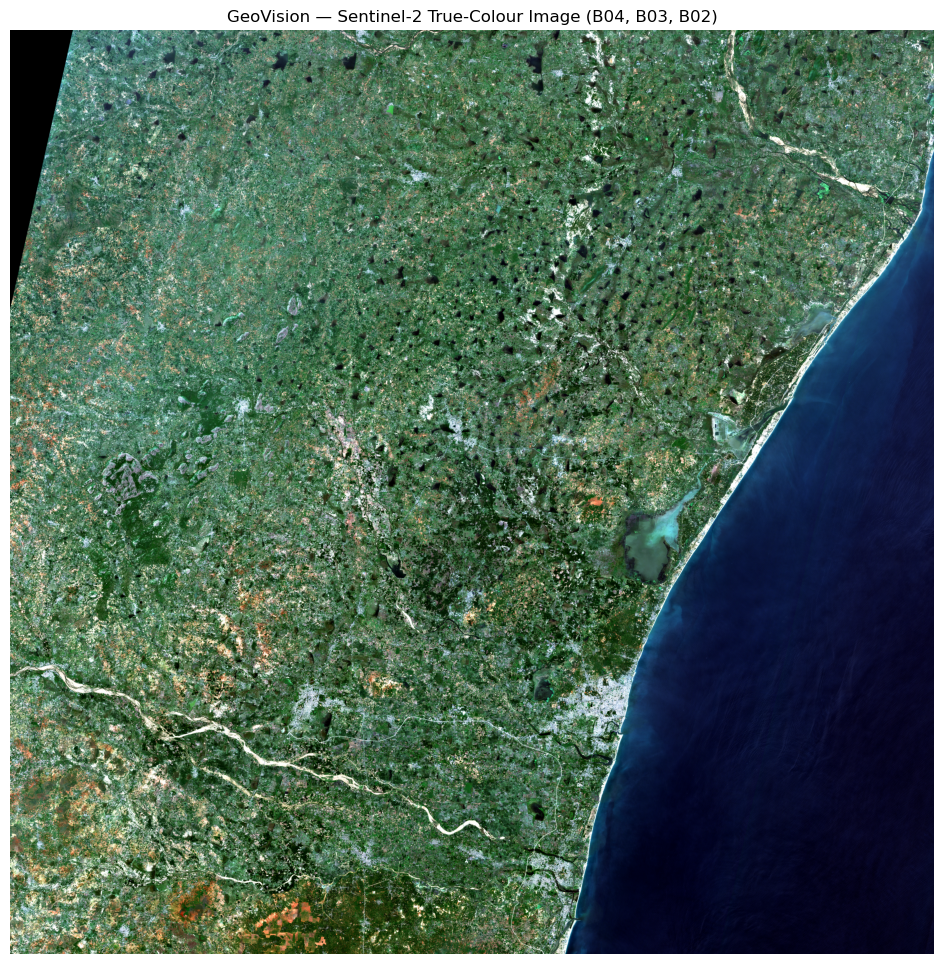

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def stretch_to_01(band, low=2, high=98):
    valid = band[band > 0]

    if len(valid) == 0:
        raise ValueError("This band contains no valid positive pixel values.")

    vmin, vmax = np.percentile(valid, [low, high])

    result = (band - vmin) / (vmax - vmin + 1e-6)
    return np.clip(result, 0, 1)

rgb = np.dstack([
    stretch_to_01(b4),  # Red
    stretch_to_01(b3),  # Green
    stretch_to_01(b2)   # Blue
])

plt.figure(figsize=(12, 12))
plt.imshow(rgb)
plt.title("GeoVision — Sentinel-2 True-Colour Image (B04, B03, B02)")
plt.axis("off")
plt.show()

In [16]:
# Crop size in pixels: 2,000 px × 2,000 px at 10 m = 20 km × 20 km.
crop_size = 2000

# Choose a crop near the centre of valid image dimensions.
row_start = max(0, H // 2 - crop_size // 2)
col_start = max(0, W // 2 - crop_size // 2)

row_end = min(H, row_start + crop_size)
col_end = min(W, col_start + crop_size)

# Crop the 10 m bands
b2_crop = b2[row_start:row_end, col_start:col_end]
b3_crop = b3[row_start:row_end, col_start:col_end]
b4_crop = b4[row_start:row_end, col_start:col_end]
b8_crop = b8[row_start:row_end, col_start:col_end]

print("Crop shape:", b2_crop.shape)

Crop shape: (2000, 2000)


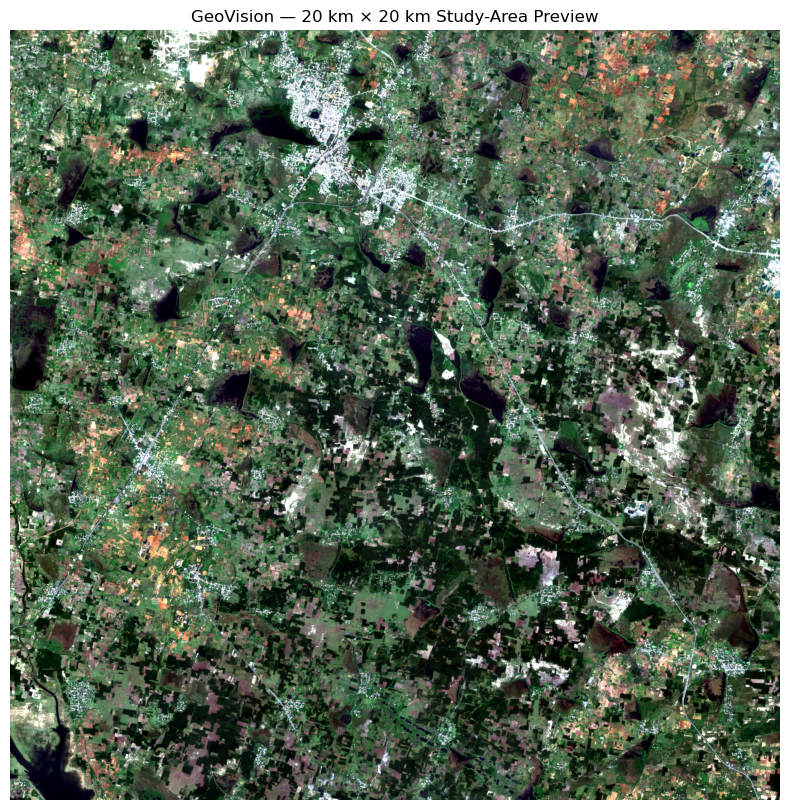

In [17]:
rgb_crop = np.dstack([
    stretch_to_01(b4_crop),
    stretch_to_01(b3_crop),
    stretch_to_01(b2_crop)
])

plt.figure(figsize=(10, 10))
plt.imshow(rgb_crop)
plt.title("GeoVision — 20 km × 20 km Study-Area Preview")
plt.axis("off")
plt.show()

In [18]:
# Shift crop to upper-left valid area
row_start = 500
col_start = 500

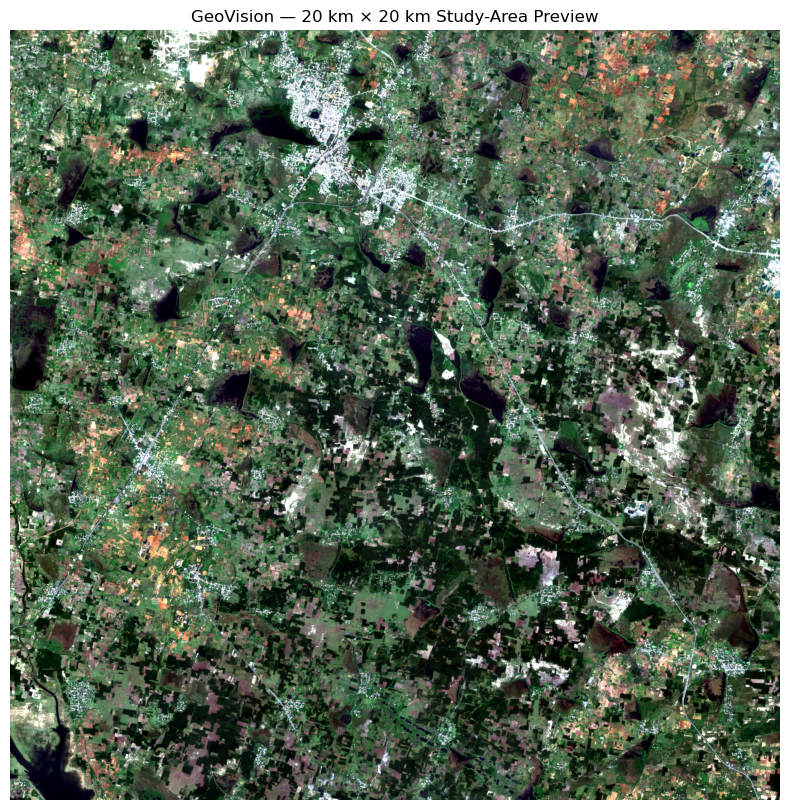

In [19]:
rgb_crop = np.dstack([
    stretch_to_01(b4_crop),
    stretch_to_01(b3_crop),
    stretch_to_01(b2_crop)
])

plt.figure(figsize=(10, 10))
plt.imshow(rgb_crop)
plt.title("GeoVision — 20 km × 20 km Study-Area Preview")
plt.axis("off")
plt.show()

In [20]:
print("Available Sentinel-2 scenes:")

for item in data_raw_dir.iterdir():
    if item.is_dir():
        print("-", item.name)

Available Sentinel-2 scenes:
- S2A_MSIL1C_20231116T050051_N0510_R119_T44PLV_20241016T094903.SAFE
- S2B_MSIL2A_20240916T045659_N0511_R119_T44PMU_20240916T085059.SAFE
- S2B_MSIL2A_20241026T045819_N0511_R119_T44PLU_20241026T080431.SAFE


In [21]:
from rasterio.warp import reproject, Resampling

# Confirm that the L2A scene has its 20 m band folder
if scene_dir_20m is None:
    raise FileNotFoundError(
        "R20m was not found. Confirm that the selected scene is Sentinel-2 Level-2A."
    )

def find_band_file(folder, band_name, resolution):
    patterns = [
        f"*_{band_name}_{resolution}.jp2",
        f"*_{band_name}_{resolution}.tif",
        f"*{band_name}_{resolution}.jp2",
        f"*{band_name}_{resolution}.tif",
    ]

    for pattern in patterns:
        candidates = list(folder.glob(pattern))
        if candidates:
            return candidates[0]

    raise FileNotFoundError(
        f"Could not find {band_name} at {resolution} inside:\n{folder}"
    )

b11_path = find_band_file(scene_dir_20m, "B11", "20m")
b12_path = find_band_file(scene_dir_20m, "B12", "20m")

print("B11 path:", b11_path.name)
print("B12 path:", b12_path.name)

def read_and_resample_to_10m(path, target_shape, target_transform, target_crs):
    with rasterio.open(path) as src:
        source = src.read(1).astype("float32")
        destination = np.zeros(target_shape, dtype=np.float32)

        reproject(
            source=source,
            destination=destination,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=target_transform,
            dst_crs=target_crs,
            resampling=Resampling.bilinear
        )

    return destination

b11 = read_and_resample_to_10m(
    b11_path,
    target_shape=(H, W),
    target_transform=transform,
    target_crs=crs
)

b12 = read_and_resample_to_10m(
    b12_path,
    target_shape=(H, W),
    target_transform=transform,
    target_crs=crs
)

print("B11 shape after resampling:", b11.shape)
print("B12 shape after resampling:", b12.shape)

B11 path: T44PLU_20241026T045819_B11_20m.jp2
B12 path: T44PLU_20241026T045819_B12_20m.jp2
B11 shape after resampling: (10980, 10980)
B12 shape after resampling: (10980, 10980)


In [22]:
eps = 1e-6

# Normalized Difference Vegetation Index
ndvi = (b8 - b4) / (b8 + b4 + eps)

# Normalized Difference Water Index
ndwi = (b3 - b8) / (b3 + b8 + eps)

# Normalized Difference Built-up Index
ndbi = (b11 - b8) / (b11 + b8 + eps)

# Pixels with values in all bands are usable for modeling.
valid_mask = (
    (b2 > 0) &
    (b3 > 0) &
    (b4 > 0) &
    (b8 > 0) &
    (b11 > 0) &
    (b12 > 0)
)

# Random Forest input: 6 original spectral bands + 3 derived indices.
stack_features = np.stack(
    [b2, b3, b4, b8, b11, b12, ndvi, ndwi, ndbi],
    axis=-1
).astype("float32")

print("Final feature stack shape:", stack_features.shape)
print("Features per pixel:", stack_features.shape[-1])
print("Valid pixels:", int(valid_mask.sum()))

Final feature stack shape: (10980, 10980, 9)
Features per pixel: 9
Valid pixels: 119319896
